# Detailed Balance and the Shockley-Queisser Limit

#### Pre-requisites:
* Band Structure (for the band gap)

1) Import the necessary libraries.

In [ ]:
import solphin.band_structure as band_structure
import solphin.db_fom as db_fom
import solphin.db_plots as db_plots

2) Define the cell operating temperature, the chosen spectrum, and the illuminance (if necessary).

In [5]:
print("Available Spectra:")
for name in db_fom.SPECTRUM_FILES.keys():
    print(name)

Available Spectra:
AM1.5
Fluorescent
Blue LED
Green LED
Red LED
White LED
IR LED
LED-B1
LED-B2
LED-B3
LED-B4
LED-B5
LED-BH1
LED-RGB1
LED-V1
LED-V2


In [6]:
Tcell = 300  # Operating Temperature (K)

spectrum_type = "AM1.5"
target_lux = 1000  # Illuminance the indoor spectra are normalised to (ignored for AM1.5 outdoor)

3) Load or specify the band gap

In [ ]:
bs = band_structure.get_band_structure("../tests/data/Cu2GeS3/BAND_SP_HDFT", splits=7, code="vasp")
E_gap_fundamental = bs.get_band_gap()["energy"]

print(f"Loaded band gap of {E_gap_fundamental:.2f} eV")

Loaded band gap of 1.39 eV


4. Load the spectrum

In [10]:
spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type, target_lux=target_lux)
photon_spectrum = db_fom.convert_spectrum(spectrum)

5. Plot the Detailed Balance and Shockley-Queisser analysis

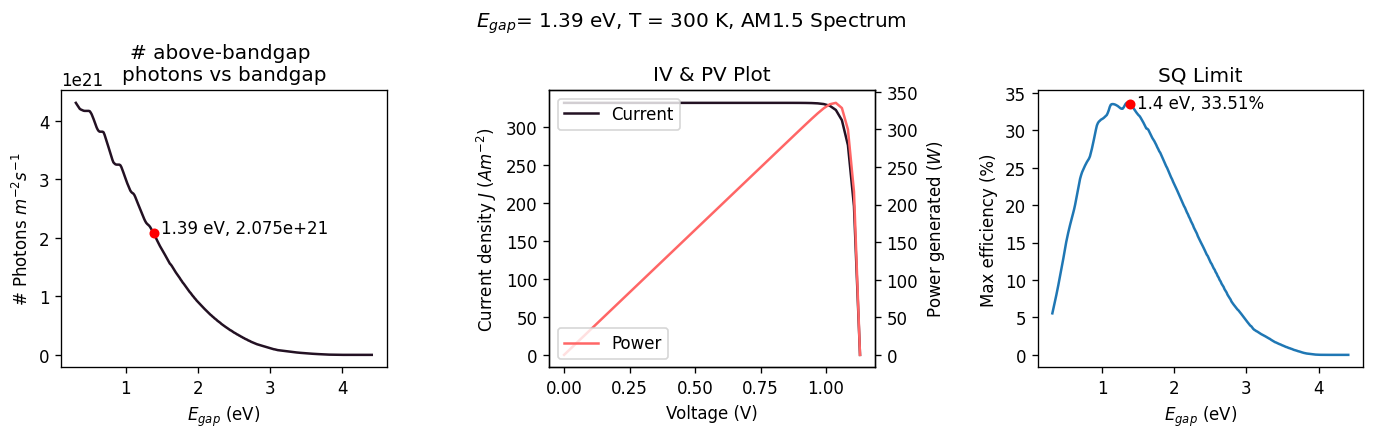

In [19]:
%matplotlib inline
db_plots.plot_db_combined(spectrum=photon_spectrum, Egap=E_gap_fundamental, Tcell=Tcell,
                             spectrum_type=spectrum_type, target_lux=target_lux)